Loaded tips dataset: (244, 7)

1.

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object
Mean total_bill: 19.79
Day value counts:
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64
Numerical  : ['total_bill', 'tip', 'size']
Categorical: ['sex', 'smoker', 'day', 'time']

1-1
Numerical columns: ['total_bill', 'tip', 'size']
Categorical columns: ['sex', 'smoker', 'day', 'time']

1-2
Mean of tip: 2.99827868852459

1-3
Value counts of sex:
sex
Male      157
Female     87
Name: count, dtype: int64

2.

Mean   : 19.79
Median : 17.8
Mode   : 13.42
mean > median ? True -> right-skewed


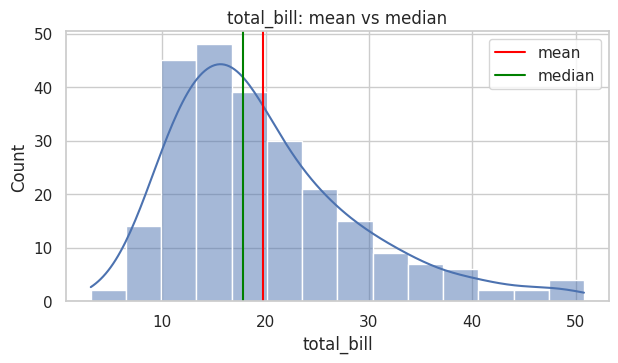


2-1
Mean: 2.99827868852459
Median: 2.9
Mode: [2.0]

2-2
Is mean > median? True
The tip distribution is right-skewed.

2-3


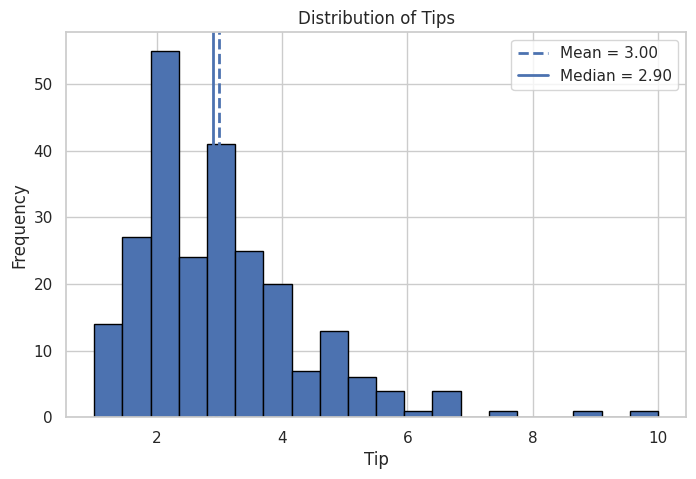


3.

Range : 47.74
Var   : 79.25
Std   : 8.9
Q1 (25%): 13.35
Q3 (75%): 24.13
IQR     : 10.78 -> spread of the middle 50% (robust to outliers)
3-1
Range: 9.0
Variance: 1.9144546380624725
Standard deviation: 1.3836381890011826
3-2
Q1: 2.0
Q3: 3.5625
IQR: 1.5625

4.

min     3.0700
25%    13.3475
50%    17.7950
75%    24.1275
max    50.8100
Name: total_bill, dtype: float64

Skewness: 1.133


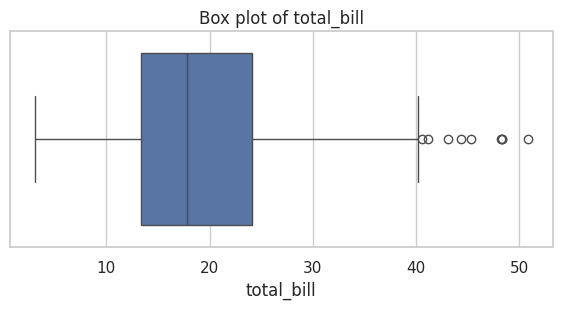

4-1
Five-number summary:
min     1.0000
25%     2.0000
50%     2.9000
75%     3.5625
max    10.0000
Name: tip, dtype: float64
4-2
Skewness: 1.4654510370979401
4-3


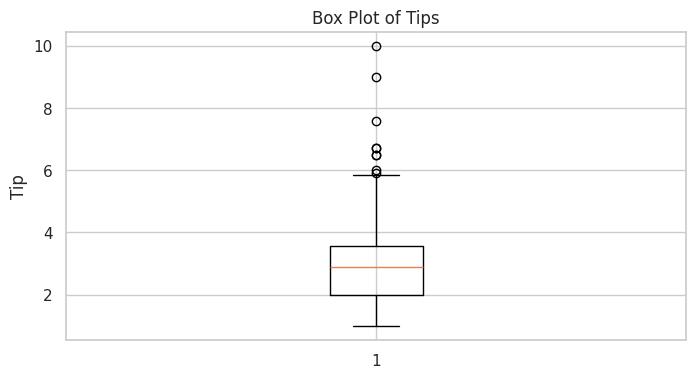


5.

5-1
Correlation Matrix:
            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00

total_bill vs tip: 0.68 -> strong positive
5-2


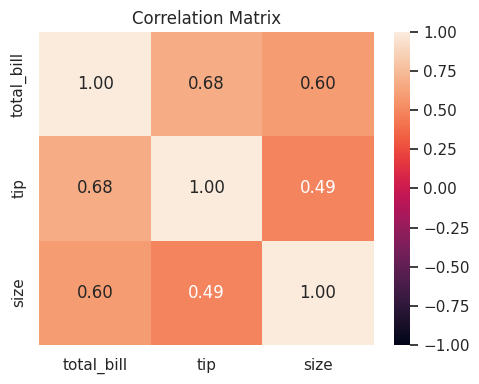

5-3

5-3
Descriptive Statistics:
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
np.random.seed(42)
df = sns.load_dataset('tips')
print('Loaded tips dataset:', df.shape)
df.head()

print("\n1.\n")
print(df.dtypes)
# Numerical -> mean / std make sense
print('Mean total_bill:', round(df['total_bill'].mean(), 2))
# Categorical -> counts / mode make sense (mean would be meaningless)
print('Day value counts:')
print(df['day'].value_counts())
numerical   = df.select_dtypes(include='number').columns.tolist()
categorical = df.select_dtypes(exclude='number').columns.tolist()
print('Numerical  :', numerical)
print('Categorical:', categorical)


#LAB EXERCISE 1 — Classify the columns
#Print the list of numerical columns and the list of categorical columns.
#For a numerical column (e.g. tip), print its mean.
#For a categorical column (e.g. sex), print its value counts.

# 1. Numerical vs categorical columns
print("\n1-1")
numerical = df.select_dtypes(include='number').columns.tolist()
categorical = df.select_dtypes(exclude='number').columns.tolist()
print("Numerical columns:", numerical)
print("Categorical columns:", categorical)

print("\n1-2")
# 2. Mean of a numerical column (tip)
print("Mean of tip:", df['tip'].mean())

print("\n1-3")
# 3. Value counts of a categorical column (sex)
print("Value counts of sex:")
print(df['sex'].value_counts())

print("\n2.\n")
#2A. MEAN, MEDIAN, MODE
col = df['total_bill']
print('Mean   :', round(col.mean(), 2))    # average; sensitive to outliers
print('Median :', round(col.median(), 2))  # middle value; robust to outliers
print('Mode   :', round(col.mode()[0], 2)) # most frequent value
# 2B. WHEN MEAN AND MEDIAN DISAGREE (skew)
# A right-skewed column drags the mean above the median
print('mean > median ?', col.mean() > col.median(), '-> right-skewed')
plt.figure(figsize=(7, 3.5))
sns.histplot(col, kde=True)
plt.axvline(col.mean(),   color='red',   label='mean')
plt.axvline(col.median(), color='green', label='median')
plt.legend(); plt.title('total_bill: mean vs median'); plt.show()

#LAB EXERCISE 2 — Central tendency
#For the tip column:
tip = df['tip']
#Print its mean, median and mode.
#Is it right-skewed? Check whether mean > median.
#Plot a histogram of tip with vertical lines at the mean and median.

print("\n2-1")
# 1. mean, median, mode
mean_tip = tip.mean()
median_tip = tip.median()
mode_tip = tip.mode()
print("Mean:", mean_tip)
print("Median:", median_tip)
print("Mode:", mode_tip.tolist())

print("\n2-2")
# 2. mean > median ?
print("Is mean > median?", mean_tip > median_tip)
if mean_tip > median_tip:
    print("The tip distribution is right-skewed.")
else:
    print("The tip distribution is not right-skewed based on mean > median.")

print("\n2-3")
# 3. histogram with mean & median lines (reuse the pattern from 2B)
plt.figure(figsize=(8, 5))
plt.hist(tip, bins=20, edgecolor='black')
plt.axvline(mean_tip, linestyle='--', linewidth=2, label=f'Mean = {mean_tip:.2f}')
plt.axvline(median_tip, linestyle='-', linewidth=2, label=f'Median = {median_tip:.2f}')
plt.xlabel('Tip')
plt.ylabel('Frequency')
plt.title('Distribution of Tips')
plt.legend()
plt.show()

print("\n3.\n")
#3A. RANGE, VARIANCE, STANDARD DEVIATION
col = df['total_bill']
print('Range :', round(col.max() - col.min(), 2))   # max - min
print('Var   :', round(col.var(), 2))                # variance (sigma^2)
print('Std   :', round(col.std(), 2))                # std deviation (sigma)
# 3B. QUARTILES & THE INTERQUARTILE RANGE (IQR)
q1, q3 = col.quantile(0.25), col.quantile(0.75)
iqr = q3 - q1
print('Q1 (25%):', round(q1, 2))
print('Q3 (75%):', round(q3, 2))
print('IQR     :', round(iqr, 2), '-> spread of the middle 50% (robust to outliers)')

"""LAB EXERCISE 3 — Spread
For the tip column:
Print the range, variance and standard deviation.
Compute Q1, Q3 and the IQR.
In a comment, say which measure of spread is most robust to outliers and why."""
tip = df['tip']
print("3-1")
# 1. Range, variance, standard deviation
tip_range = tip.max() - tip.min()
tip_variance = tip.var()
tip_std = tip.std()
print("Range:", tip_range)
print("Variance:", tip_variance)
print("Standard deviation:", tip_std)

print("3-2")
# 2. Q1, Q3, IQR
Q1 = tip.quantile(0.25)
Q3 = tip.quantile(0.75)
IQR = Q3 - Q1
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

#3-3
# 3.Most robust measure of spread
# IQR is the most robust to outliers because it only uses
# the middle 50% of the data and is not strongly affected
# by extreme values.

print("\n4.\n")
#4A. FIVE-NUMBER SUMMARY (min, Q1, median, Q3, max)
col = df['total_bill']
five = col.describe()[['min', '25%', '50%', '75%', 'max']]
print(five)
# Skewness: > 0 means a right tail, < 0 a left tail, ~0 symmetric
print('\nSkewness:', round(col.skew(), 3))
# 4B. BOX PLOT (a picture of the five-number summary)
# The box spans Q1..Q3 (the IQR), the line is the median,
# whiskers reach the rest, and dots beyond them are outliers.
plt.figure(figsize=(7, 2.8))
sns.boxplot(x=df['total_bill'])
plt.title('Box plot of total_bill'); plt.show()

"""For the tip column:
   Print its five-number summary (min, 25%, 50%, 75%, max).
   Print its skewness and say (in a comment) which way it leans.
   Draw a box plot of tip."""

tip = df['tip']
print("4-1")
# 1. five-number summary
five_number_summary = tip.describe()[['min', '25%', '50%', '75%', 'max']]
print("Five-number summary:")
print(five_number_summary)

print("4-2")
# 2. skewness
skewness = tip.skew()
print("Skewness:", skewness)

print("4-3")
# 3. box plot of tip
plt.figure(figsize=(8, 4))
plt.boxplot(tip)
plt.ylabel('Tip')
plt.title('Box Plot of Tips')
plt.show()

print("\n5.\n")
# 5A. CORRELATION BETWEEN NUMERICAL COLUMNS
# .corr() returns correlations between -1 and +1
print("5-1")
corr = df.corr(numeric_only=True)
print("Correlation Matrix:")
print(corr.round(2))
# Correlation is NOT causation.
# It only measures linear relationships.
print(
    "\ntotal_bill vs tip:",
    round(corr.loc['total_bill', 'tip'], 2),
    "-> strong positive"
)
print("5-2")
# 5B. VISUALISE THE CORRELATION MATRIX
plt.figure(figsize=(5, 4))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()
# Close the figure after displaying it
plt.close()
print("5-3")
# 5C. ONE-SHOT SUMMARY
print("\n5-3")
print("Descriptive Statistics:")
print(df.describe())


# -----------------------------------------------------------
# 3 INSIGHTS
# -----------------------------------------------------------

# Insight 1: total_bill has the largest spread among the
# numerical columns.
#
# Insight 2: total_bill and tip have the strongest positive
# correlation.
#
# Insight 3: tip is slightly right-skewed because its mean
# is greater than its median.

